Cleaned summary data:


,run,duration_ms,unique_files,total_allocs
0,1,216,23,7612
1,2,195,19,5625
2,3,176,15,5121
3,4,216,18,5127
4,5,214,16,5058


Allocation data sample:


,run,order,count
0,1,0,7518
1,1,1,84
2,1,2,4
3,1,3,3
4,2,0,5487


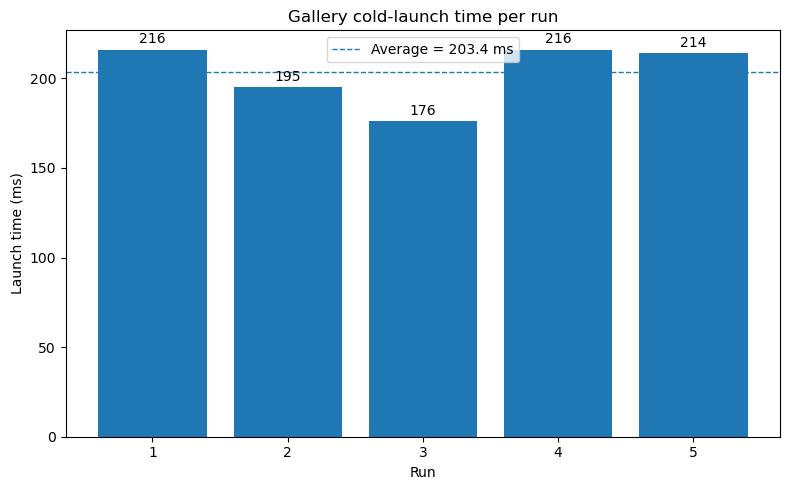

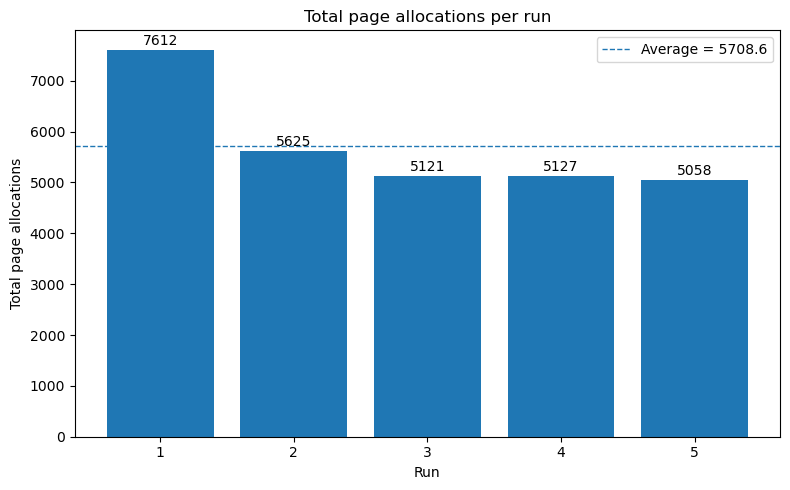

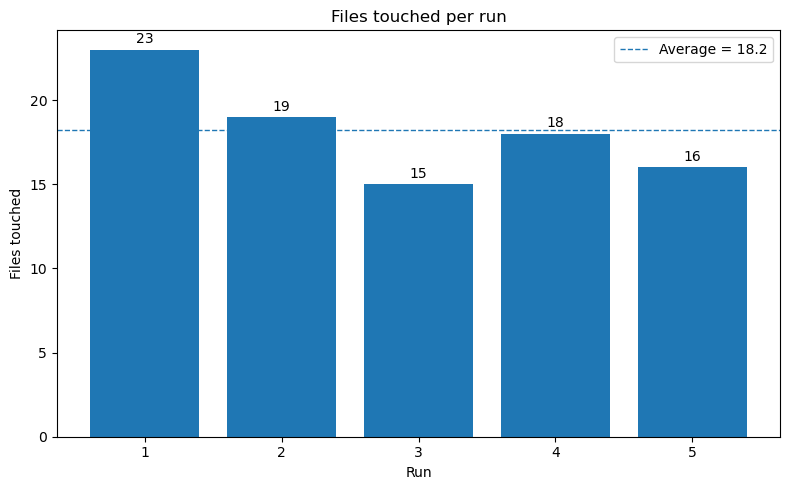

Allocation-order pivot table:


order,0,1,2,3,4
run,,,,,
1,7518,84,4,3,0
2,5487,116,13,3,2
3,5032,82,4,0,0
4,5021,97,4,2,0
5,4974,79,2,0,0


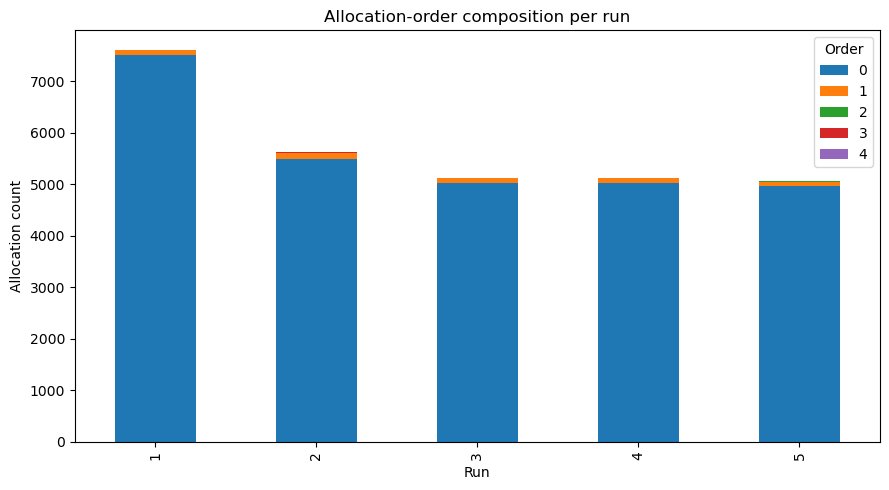


Saved figures:
 - C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results\figures_clean\launch_time_per_run_bar.png
 - C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results\figures_clean\total_allocs_per_run_bar.png
 - C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results\figures_clean\files_touched_per_run_bar.png
 - C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results\figures_clean\alloc_orders_stacked_per_run.png

Saved tables:
 - C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results\figures_clean\summary_clean.csv
 - C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results\figures_clean\alloc_orders_pivot.csv


In [24]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
RESULTS_DIR = r"C:\Users\Fathey\Downloads\OS_Project\eBPF\exploration\ebpf_results"
OUT_DIR = os.path.join(RESULTS_DIR, "figures_clean")
os.makedirs(OUT_DIR, exist_ok=True)

# =========================
# LOAD SUMMARY
# =========================
summary_path = os.path.join(RESULTS_DIR, "summary.csv")
if not os.path.exists(summary_path):
    raise FileNotFoundError(f"summary.csv not found in {RESULTS_DIR}")

summary_df = pd.read_csv(summary_path)

# Keep only one row per run.
# If duplicates exist, keep the last one.
summary_df = (
    summary_df.sort_values("run")
    .drop_duplicates(subset=["run"], keep="last")
    .reset_index(drop=True)
)

# Convert expected columns safely
for col in ["run", "duration_ms", "unique_files", "total_allocs"]:
    if col in summary_df.columns:
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

summary_df = summary_df.dropna(subset=["run", "duration_ms", "unique_files", "total_allocs"])
summary_df["run"] = summary_df["run"].astype(int)
summary_df = summary_df.sort_values("run").reset_index(drop=True)

print("Cleaned summary data:")
display(summary_df[["run", "duration_ms", "unique_files", "total_allocs"]])

# =========================
# LOAD ALLOCATION CSV FILES
# =========================
alloc_paths = sorted(glob.glob(os.path.join(RESULTS_DIR, "run_*_alloc.csv")))
if not alloc_paths:
    raise FileNotFoundError("No run_*_alloc.csv files found")

alloc_frames = []
for path in alloc_paths:
    df = pd.read_csv(path)
    alloc_frames.append(df)

alloc_df = pd.concat(alloc_frames, ignore_index=True)

for col in ["run", "order", "count"]:
    alloc_df[col] = pd.to_numeric(alloc_df[col], errors="coerce")

alloc_df = alloc_df.dropna(subset=["run", "order", "count"])
alloc_df["run"] = alloc_df["run"].astype(int)
alloc_df["order"] = alloc_df["order"].astype(int)
alloc_df["count"] = alloc_df["count"].astype(int)

print("Allocation data sample:")
display(alloc_df.head())

# =========================
# FIGURE 1: LAUNCH TIME PER RUN
# =========================
plt.figure(figsize=(8, 5))
plt.bar(summary_df["run"].astype(str), summary_df["duration_ms"])
plt.xlabel("Run")
plt.ylabel("Launch time (ms)")
plt.title("Gallery cold-launch time per run")

avg_launch = summary_df["duration_ms"].mean()
plt.axhline(avg_launch, linestyle="--", linewidth=1, label=f"Average = {avg_launch:.1f} ms")
plt.legend()

for x, y in zip(summary_df["run"].astype(str), summary_df["duration_ms"]):
    plt.text(x, y + 2, f"{int(y)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
launch_time_path = os.path.join(OUT_DIR, "launch_time_per_run_bar.png")
plt.savefig(launch_time_path, dpi=220, bbox_inches="tight")
plt.show()

# =========================
# FIGURE 2: TOTAL PAGE ALLOCS PER RUN
# =========================
plt.figure(figsize=(8, 5))
plt.bar(summary_df["run"].astype(str), summary_df["total_allocs"])
plt.xlabel("Run")
plt.ylabel("Total page allocations")
plt.title("Total page allocations per run")

avg_allocs = summary_df["total_allocs"].mean()
plt.axhline(avg_allocs, linestyle="--", linewidth=1, label=f"Average = {avg_allocs:.1f}")
plt.legend()

for x, y in zip(summary_df["run"].astype(str), summary_df["total_allocs"]):
    plt.text(x, y + 40, f"{int(y)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
alloc_total_path = os.path.join(OUT_DIR, "total_allocs_per_run_bar.png")
plt.savefig(alloc_total_path, dpi=220, bbox_inches="tight")
plt.show()

# =========================
# FIGURE 3: FILES TOUCHED PER RUN
# =========================
plt.figure(figsize=(8, 5))
plt.bar(summary_df["run"].astype(str), summary_df["unique_files"])
plt.xlabel("Run")
plt.ylabel("Files touched")
plt.title("Files touched per run")

avg_files = summary_df["unique_files"].mean()
plt.axhline(avg_files, linestyle="--", linewidth=1, label=f"Average = {avg_files:.1f}")
plt.legend()

for x, y in zip(summary_df["run"].astype(str), summary_df["unique_files"]):
    plt.text(x, y + 0.2, f"{int(y)}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
files_touched_path = os.path.join(OUT_DIR, "files_touched_per_run_bar.png")
plt.savefig(files_touched_path, dpi=220, bbox_inches="tight")
plt.show()

# =========================
# FIGURE 4: ALLOCATION-ORDER COMPOSITION PER RUN
# =========================
alloc_pivot = alloc_df.pivot_table(
    index="run",
    columns="order",
    values="count",
    aggfunc="sum",
    fill_value=0
).sort_index()

print("Allocation-order pivot table:")
display(alloc_pivot)

ax = alloc_pivot.plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_xlabel("Run")
ax.set_ylabel("Allocation count")
ax.set_title("Allocation-order composition per run")
ax.legend(title="Order")
plt.tight_layout()

alloc_stacked_path = os.path.join(OUT_DIR, "alloc_orders_stacked_per_run.png")
plt.savefig(alloc_stacked_path, dpi=220, bbox_inches="tight")
plt.show()

# =========================
# SAVE HELPER TABLES
# =========================
summary_df[["run", "duration_ms", "unique_files", "total_allocs"]].to_csv(
    os.path.join(OUT_DIR, "summary_clean.csv"), index=False
)

alloc_pivot.to_csv(os.path.join(OUT_DIR, "alloc_orders_pivot.csv"))

print("\nSaved figures:")
print(" -", launch_time_path)
print(" -", alloc_total_path)
print(" -", files_touched_path)
print(" -", alloc_stacked_path)

print("\nSaved tables:")
print(" -", os.path.join(OUT_DIR, "summary_clean.csv"))
print(" -", os.path.join(OUT_DIR, "alloc_orders_pivot.csv"))